<a href="https://colab.research.google.com/github/Arebu18/ArebMY/blob/main/advanced_fraud_detection_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Apache Spark Credit Card Fraud Detection
Deep Autoencoders + Graph Neural Networks + Unsupervised Learning

In [1]:
# Install Required Libraries
!pip install pyspark tensorflow torch torch-geometric scikit-learn pandas numpy matplotlib networkx streamlit pyngrok -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 52.2 MB/s eta 0:00:00


In [70]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
from pyspark.ml.feature import PCA
from pyspark.ml.clustering import KMeans

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

import networkx as nx


In [71]:
# Start Spark Session

spark = SparkSession.builder \
    .appName("AdvancedFraudDetection") \
    .getOrCreate()

print("Spark Session Started")


Spark Session Started


In [ ]:
# Upload Dataset

from google.colab import files
uploaded = files.upload()

In [72]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [73]:
spark_df = spark.read.csv(
    '/content/card_transdata.csv',
    header=True,
    inferSchema=True
)

In [8]:
spark_df.show(5)

+------------------+------------------------------+------------------------------+---------------+---------+---------------+------------+-----+
|distance_from_home|distance_from_last_transaction|ratio_to_median_purchase_price|repeat_retailer|used_chip|used_pin_number|online_order|fraud|
+------------------+------------------------------+------------------------------+---------------+---------+---------------+------------+-----+
| 57.87785658389723|            0.3111400080477545|            1.9459399775518593|            1.0|      1.0|            0.0|         0.0|  0.0|
|10.829942699255545|           0.17559150228166587|            1.2942188106198573|            1.0|      0.0|            0.0|         0.0|  0.0|
| 5.091079490616996|            0.8051525945853258|           0.42771456119427587|            1.0|      0.0|            0.0|         1.0|  0.0|
|2.2475643282963613|              5.60004354707232|           0.36266257805709584|            1.0|      1.0|            0.0|         1.0

In [ ]:
# Load Dataset with Spark

spark_df = spark.read.csv(
    'creditcard.csv',
    header=True,
    inferSchema=True
)

spark_df.show(5)

In [75]:
# Data Preprocessing

spark_df = spark_df.dropna()

feature_cols = spark_df.columns[:-1]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol='features'
)

assembled_df = assembler.transform(spark_df)

scaler = StandardScaler(
    inputCol='features',
    outputCol='scaledFeatures',
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(assembled_df)
scaled_df = scaler_model.transform(assembled_df)

pca = PCA(
    k=len(feature_cols),
    inputCol='scaledFeatures',
    outputCol='pcaFeatures'
)

pca_model = pca.fit(scaled_df)
pca_df = pca_model.transform(scaled_df)

final_df = pca_df.select('pcaFeatures', 'fraud')

final_df.show(5)

+--------------------+-----+
|         pcaFeatures|fraud|
+--------------------+-----+
|[-0.5996964672222...|  0.0|
|[-0.1120675966495...|  0.0|
|[-0.0310409333247...|  0.0|
|[0.02140780628395...|  0.0|
|[-0.4327412251731...|  0.0|
+--------------------+-----+
only showing top 5 rows


In [76]:
# Convert Spark DataFrame to Pandas

pandas_df = final_df.toPandas()

X = pd.DataFrame(
    pandas_df['pcaFeatures'].tolist()
)

y = pandas_df['fraud']

print(X.shape)


(1000000, 7)


In [77]:
# ==========================================
# ISOLATION FOREST
# ==========================================

iso_model = IsolationForest(
    n_estimators=200,
    #contamination=0.002,
    contamination=0.01,
    random_state=42
)

iso_model.fit(X)

iso_pred = iso_model.predict(X)

iso_pred = np.where(
    iso_pred == -1,
    1,
    0
)

print("Isolation Forest Fraud:",
      np.sum(iso_pred))

Isolation Forest Fraud: 10000


In [78]:
# ==========================================
# LOCAL OUTLIER FACTOR
# ==========================================

lof = LocalOutlierFactor(
    n_neighbors=20,
    #contamination=0.002
    contamination=0.01
)

lof_pred = lof.fit_predict(X)

lof_pred = np.where(
    lof_pred == -1,
    1,
    0
)

print("LOF Fraud:",
      np.sum(lof_pred))

LOF Fraud: 10000


In [79]:
# Deep Autoencoder
# ==========================================
# TRAIN AUTOENCODER ONLY ON NORMAL DATA
# ==========================================

normal_data = X[y == 0]

X_train, X_test = train_test_split(
    normal_data,
    test_size=0.2,
    random_state=42
)

input_dim = X_train.shape[1]

# Input Layer
input_layer = Input(shape=(input_dim,))

# Encoder
encoder = Dense(128, activation='relu')(input_layer)
encoder = Dropout(0.2)(encoder)

encoder = Dense(64, activation='relu')(encoder)
encoder = Dense(32, activation='relu')(encoder)
encoder = Dense(16, activation='relu')(encoder)
encoder = Dense(8, activation='relu')(encoder)

# Bottleneck
bottleneck = Dense(4, activation='relu')(encoder)

# Decoder
decoder = Dense(8, activation='relu')(bottleneck)
decoder = Dense(16, activation='relu')(decoder)
decoder = Dense(32, activation='relu')(decoder)
decoder = Dense(64, activation='relu')(decoder)
decoder = Dense(128, activation='relu')(decoder)

output_layer = Dense(
    input_dim,
    activation='linear'
)(decoder)

# Build Model
autoencoder = Model(
    inputs=input_layer,
    outputs=output_layer
)

# Compile
autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train Model
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
2282/2282 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - loss: 0.1891 - val_loss: 0.0577
Epoch 2/30
2282/2282 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0646 - val_loss: 0.1388
Epoch 3/30
2282/2282 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0813 - val_loss: 0.1699
Epoch 4/30
2282/2282 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0823 - val_loss: 0.0432
Epoch 5/30
2282/2282 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0547 - val_loss: 0.0991
Epoch 6/30
2282/2282 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0864 - val_loss: 0.0443
Epoch 7/30
2282/2282 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0504 - val_loss: 0.0467
Epoch 8/30
2282/2282 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0528 - val_loss: 0.0375
Epoch 9/30
2282/2282 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0427 - val_loss: 0.0372
Epoch 10/30
2282/2282 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0744 - val_loss: 0.0311
Epoch 11/30
2282/2282 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0461 - val_loss: 0.0298
Epoch 12/30
2282/2282 

In [93]:
# ==========================================
# TEST ON FULL DATASET
# ==========================================

reconstructions = autoencoder.predict(X)

# Reconstruction Error
mse = np.mean(
    np.power(X - reconstructions, 2),
    axis=1
)

# Improved Threshold
#threshold = np.mean(mse) + 1.2* np.std(mse)
threshold = np.percentile(mse, 85)

print("Threshold:", threshold)

# Fraud Predictions
autoencoder_pred = (
    mse > threshold
).astype(int)

print("Fraud Predictions:",
      np.sum(autoencoder_pred))

print("Normal Predictions:",
      np.sum(autoencoder_pred == 0))

31250/31250 ━━━━━━━━━━━━━━━━━━━━ 66s 2ms/step
Threshold: 0.06560050493399232
Fraud Predictions: 150000
Normal Predictions: 850000


In [94]:
# ==========================================
# IMPROVED GNN MODEL
# ==========================================

class GNNModel(torch.nn.Module):

    def __init__(self, input_dim):

        super(GNNModel, self).__init__()

        self.conv1 = GCNConv(input_dim, 128)
        self.conv2 = GCNConv(128, 64)
        self.conv3 = GCNConv(64, 32)

        self.dropout = torch.nn.Dropout(0.3)

        self.fc1 = torch.nn.Linear(32, 16)
        self.fc2 = torch.nn.Linear(16, 2)

    def forward(self, data):

        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x = F.relu(x)

        x = self.fc1(x)
        x = F.relu(x)

        x = self.fc2(x)

        return F.log_softmax(x, dim=1)

# Initialize Model
model = GNNModel(sample_X.shape[1])

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=5e-4
)

In [98]:
# ==========================================
# Graph Neural Network
# ==========================================

num_samples = 400 # Or choose a different number if needed
sample_X = X.iloc[:num_samples]
sample_y = y.iloc[:num_samples]
# Create the graph with the same number of nodes as sample_X
G = nx.erdos_renyi_graph(sample_X.shape[0], 0.02)

node_features = torch.tensor(
    sample_X.values,
    dtype=torch.float
)

labels = torch.tensor(
    sample_y.values,
    dtype=torch.long
)

edge_index = torch.tensor(
    list(G.edges),
    dtype=torch.long
).t().contiguous()

graph_data = Data(
    x=node_features,
    edge_index=edge_index,
    y=labels
)

print(graph_data)

Data(x=[400, 7], edge_index=[2, 1596], y=[400])


In [104]:
from sklearn.metrics import roc_auc_score

# Ensure gnn_probs are aligned with true_labels
gnn_roc_auc = roc_auc_score(true_labels[:len(gnn_probs)], gnn_probs)

print(f"GNN Model ROC AUC Score: {gnn_roc_auc:.4f}")

GNN Model ROC AUC Score: 0.8008


In [99]:
# ==========================================
# COMPUTE CLASS WEIGHTS
# ==========================================

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(sample_y),
    y=sample_y
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
)

print("Class Weights:", class_weights)

Class Weights: tensor([0.5479, 5.7143])


In [100]:
# ==========================================
# TRAIN GNN WITH WEIGHTED LOSS
# ==========================================

model.train()

for epoch in range(100):

    optimizer.zero_grad()

    out = model(graph_data)

    loss = F.nll_loss(
        out,
        graph_data.y,
        weight=class_weights
    )

    loss.backward()

    optimizer.step()

    if epoch % 15 == 0:
        print(
            f'Epoch {epoch}, Loss: {loss.item()}'
        )

Epoch 0, Loss: 0.6920175552368164
Epoch 15, Loss: 0.6707454323768616
Epoch 30, Loss: 0.6399621367454529
Epoch 45, Loss: 0.6275947690010071
Epoch 60, Loss: 0.6141627430915833
Epoch 75, Loss: 0.597113847732544
Epoch 90, Loss: 0.5755813717842102


In [101]:
# ==========================================
# GNN PREDICTIONS
# ==========================================

model.eval()

with torch.no_grad():

    pred_probs = model(graph_data)

   # pred = pred_probs.argmax(dim=1)
    gnn_probs = torch.exp(pred_probs)[:,1].numpy()

gnn_pred = pred.numpy()

print("\\nDistribution of GNN Predictions:")

print(
    pd.Series(gnn_pred).value_counts()
)

print("\\nFirst 20 Predictions:")

print(gnn_pred[:20])

\nDistribution of GNN Predictions:
0    4425
1     575
Name: count, dtype: int64
\nFirst 20 Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0]


In [102]:
# ==========================================
# ENSEMBLE FRAUD DETECTION
# ==========================================

min_length = min(
    len(iso_pred),
    len(lof_pred),
    len(autoencoder_pred)
)

# Weighted Ensemble
ensemble_score = (
   # 0.4 * iso_pred[:min_length] +
   # 0.3 * lof_pred[:min_length] +
   # 0.3 * autoencoder_pred[:min_length]

    0.2 * iso_pred[:min_length] +
    0.2 * lof_pred[:min_length] +
    0.6 * autoencoder_pred[:min_length]

)

# Improved Threshold
final_prediction = np.where(
    ensemble_score >= 0.2,
    1,
    0
)

print("Final Fraud Predictions:",
      np.sum(final_prediction))

print("Final Normal Predictions:",
      np.sum(final_prediction == 0))

Final Fraud Predictions: 154004
Final Normal Predictions: 845996


In [103]:
# ==========================================
# EVALUATION
# ==========================================

true_labels = y.iloc[:min_length]

precision = precision_score(
    true_labels,
    final_prediction,
    zero_division=0
)

recall = recall_score(
    true_labels,
    final_prediction,
    zero_division=0
)

f1 = f1_score(
    true_labels,
    final_prediction,
    zero_division=0
)

roc_auc = roc_auc_score(
    true_labels,
    final_prediction
)

print("\\n===== MODEL PERFORMANCE =====")

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

print("\\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        true_labels,
        final_prediction,
        zero_division=0
    )
)

\n===== MODEL PERFORMANCE =====
Precision: 0.5111815277525259
Recall: 0.9007013489239499
F1 Score: 0.6522097536525453
ROC-AUC: 0.9091057437861125
\n===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

         0.0       0.99      0.92      0.95    912597
         1.0       0.51      0.90      0.65     87403

    accuracy                           0.92   1000000
   macro avg       0.75      0.91      0.80   1000000
weighted avg       0.95      0.92      0.93   1000000



In [105]:
print("\n===== INDIVIDUAL MODEL ROC AUC SCORES =====")

# Ensure predictions are aligned with true_labels by taking min_length
iso_roc_auc = roc_auc_score(true_labels, iso_pred[:min_length])
lof_roc_auc = roc_auc_score(true_labels, lof_pred[:min_length])

# For the autoencoder, `autoencoder_pred` is already sized to `min_length` (1M samples)
autoencoder_roc_auc = roc_auc_score(true_labels, autoencoder_pred)

# For GNN, `gnn_probs` are probabilities and already sized to 400. Need to check alignment.
# `sample_y` (length 400) was used for GNN training, so we should use that for evaluation.
# The `gnn_roc_auc` was already calculated for the GNN using `true_labels[:len(gnn_probs)]` and `gnn_probs`.

print(f"Isolation Forest ROC-AUC: {iso_roc_auc:.4f}")
print(f"Local Outlier Factor ROC-AUC: {lof_roc_auc:.4f}")
print(f"Autoencoder ROC-AUC: {autoencoder_roc_auc:.4f}")
print(f"GNN ROC-AUC (on sample data): {gnn_roc_auc:.4f}")


===== INDIVIDUAL MODEL ROC AUC SCORES =====
Isolation Forest ROC-AUC: 0.5307
Local Outlier Factor ROC-AUC: 0.5190
Autoencoder ROC-AUC: 0.9109
GNN ROC-AUC (on sample data): 0.8008


In [89]:
print('Distribution of True Labels:')
print(true_labels.value_counts())

print('\nDistribution of Final Ensemble Predictions:')
print(pd.Series(final_prediction).value_counts())

print('\nDistribution of Isolation Forest Predictions:')
print(pd.Series(iso_pred[:min_length]).value_counts())

print('\nDistribution of Local Outlier Factor Predictions:')
print(pd.Series(lof_pred[:min_length]).value_counts())

print('\nDistribution of Autoencoder Predictions (on test set):')
# Note: autoencoder_pred was calculated on X_test, which is a subset of the data.
# For a direct comparison with the min_length subset, we'd need to re-evaluate or use a consistent subset.
# For now, let's just show the distribution for the calculated autoencoder_pred.
print(pd.Series(autoencoder_pred).value_counts())

print('\nDistribution of GNN Predictions:')
print(pd.Series(gnn_pred[:min_length]).value_counts())

Distribution of True Labels:
fraud
0.0    912597
1.0     87403
Name: count, dtype: int64

Distribution of Final Ensemble Predictions:
0    945769
1     54231
Name: count, dtype: int64

Distribution of Isolation Forest Predictions:
0    990000
1     10000
Name: count, dtype: int64

Distribution of Local Outlier Factor Predictions:
0    990000
1     10000
Name: count, dtype: int64

Distribution of Autoencoder Predictions (on test set):
0    954080
1     45920
Name: count, dtype: int64

Distribution of GNN Predictions:
0    4425
1     575
Name: count, dtype: int64


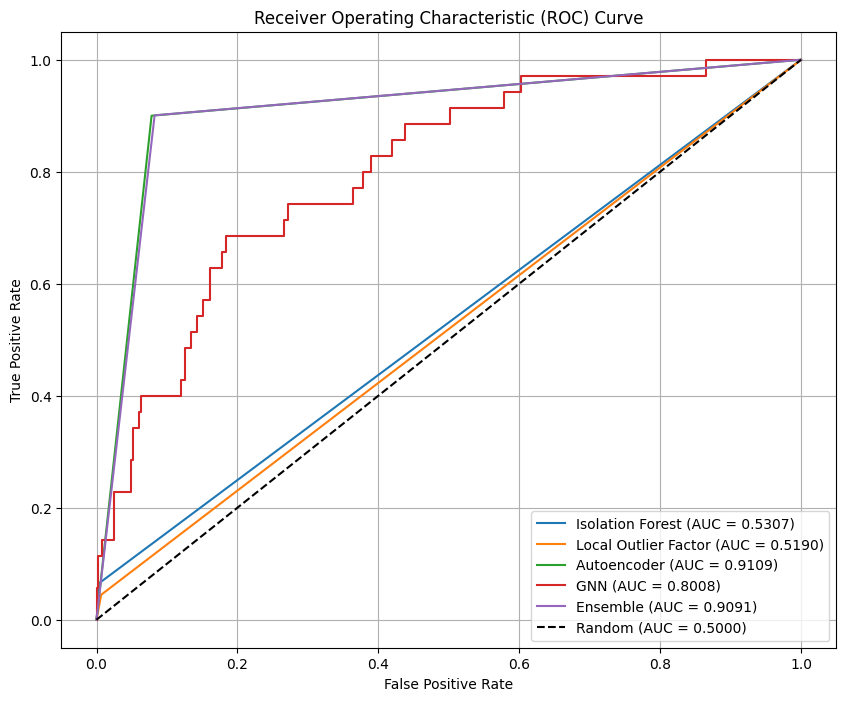

In [107]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# ROC Curve for Isolation Forest
# Note: roc_curve can handle binary predictions, resulting in a step-like curve.
# For smoother curves, decision scores/probabilities are typically used.
fpr_iso, tpr_iso, _ = roc_curve(true_labels, iso_pred[:min_length])
roc_auc_iso = auc(fpr_iso, tpr_iso)
plt.plot(fpr_iso, tpr_iso, label=f'Isolation Forest (AUC = {roc_auc_iso:.4f})')

# ROC Curve for Local Outlier Factor
fpr_lof, tpr_lof, _ = roc_curve(true_labels, lof_pred[:min_length])
roc_auc_lof = auc(fpr_lof, tpr_lof)
plt.plot(fpr_lof, tpr_lof, label=f'Local Outlier Factor (AUC = {roc_auc_lof:.4f})')

# ROC Curve for Autoencoder
fpr_ae, tpr_ae, _ = roc_curve(true_labels, autoencoder_pred)
roc_auc_ae = auc(fpr_ae, tpr_ae)
plt.plot(fpr_ae, tpr_ae, label=f'Autoencoder (AUC = {roc_auc_ae:.4f})')

# ROC Curve for GNN (using probabilities)
# gnn_probs correspond to a sample of the data, so we use sample_y for true labels
fpr_gnn, tpr_gnn, _ = roc_curve(sample_y, gnn_probs[:len(sample_y)])
roc_auc_gnn = auc(fpr_gnn, tpr_gnn)
plt.plot(fpr_gnn, tpr_gnn, label=f'GNN (AUC = {roc_auc_gnn:.4f})')

# ROC Curve for Ensemble
fpr_ensemble, tpr_ensemble, _ = roc_curve(true_labels, final_prediction)
roc_auc_ensemble = auc(fpr_ensemble, tpr_ensemble)
plt.plot(fpr_ensemble, tpr_ensemble, label=f'Ensemble (AUC = {roc_auc_ensemble:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5000)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

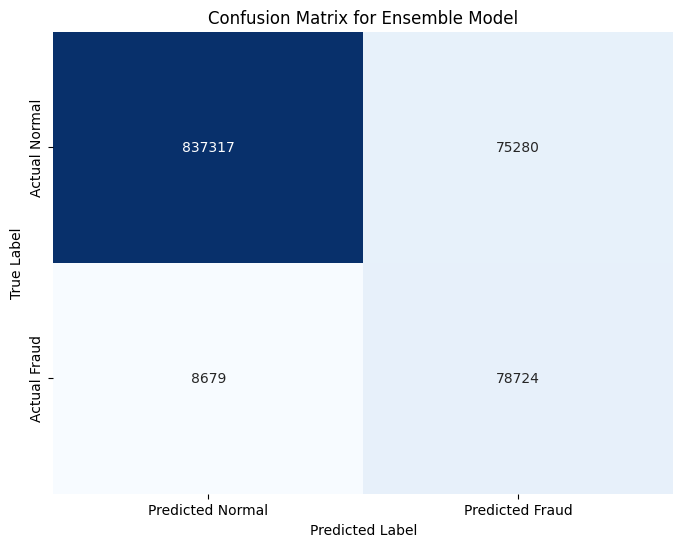

In [108]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(true_labels, final_prediction)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Ensemble Model')
plt.show()

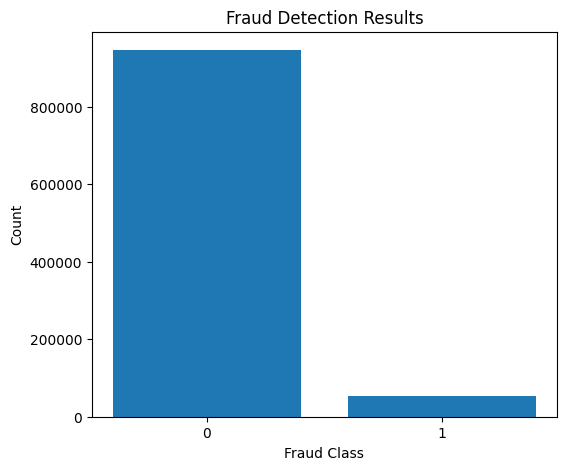

In [90]:
# Fraud Visualization

fraud_counts = pd.Series(final_prediction).value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    fraud_counts.index.astype(str),
    fraud_counts.values
)

plt.xlabel('Fraud Class')
plt.ylabel('Count')
plt.title('Fraud Detection Results')

plt.show()


In [106]:
# Save Models

autoencoder.save('deep_autoencoder_model.keras')

torch.save(
    model.state_dict(),
    'gnn_model.pth'
)

print('Models Saved Successfully')


Models Saved Successfully
